## Narrative Summary

This visualization explores **customer dining behavior**, focusing on how bill size, tipping patterns, dining time, and group size interact.  
The four panels reveal how customer characteristics and dining context influence total spending and tipping behavior.  
Together, these insights tell a cohesive story of how customer habits shape restaurant revenue trends.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("charts", exist_ok=True)
# Consistent style
sns.set_style("whitegrid")



In [19]:
# Load seaborn dataset
df = sns.load_dataset("tips")

# Preview dataset
df.head(20)



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [20]:
print(df.info())
print("\nShape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

Shape: (244, 7)


Text(0.5, 8, 'Tipping distribution varies across customer groups')

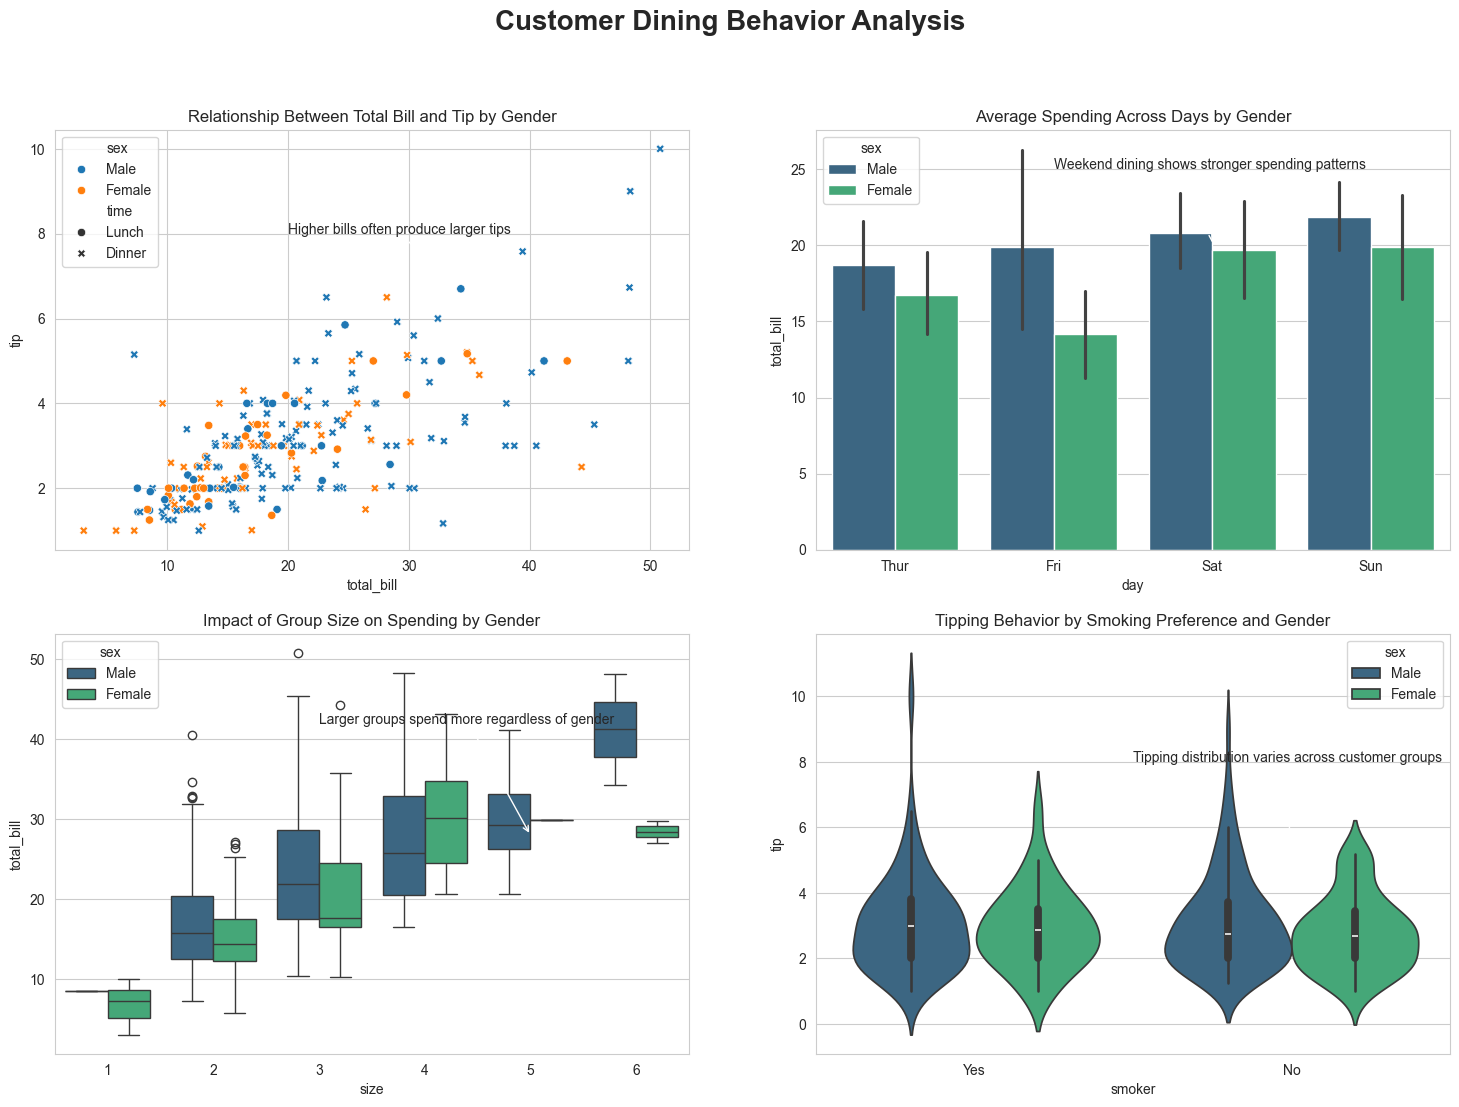

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Customer Dining Behavior Analysis", fontsize=20, fontweight='bold')

# total bill vs tip
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    style="time",
    palette= ["#1f77b4", "#ff7f0e"],
    ax=axes[0, 0]
)

axes[0, 0].set_title("Relationship Between Total Bill and Tip by Gender")
axes[0, 0].annotate(
    "Higher bills often produce larger tips",
    xy=(35, 6),
    xytext=(20, 8),
    arrowprops=dict(arrowstyle="->")
)

# average bill by day
sns.barplot(
    data=df,
    x="day",
    y="total_bill",
    hue="sex",
    palette="viridis",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Average Spending Across Days by Gender")
axes[0, 1].annotate(
    "Weekend dining shows stronger spending patterns",
    xy=(2, 20),
    xytext=(1, 25),
    arrowprops=dict(arrowstyle="->")
)

# group size distribution
sns.boxplot(
    data=df,
    x="size",
    y="total_bill",
    hue="sex",
    palette="viridis",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Impact of Group Size on Spending by Gender")
axes[1, 0].annotate(
    "Larger groups spend more regardless of gender",
    xy=(4, 28),
    xytext=(2, 42),
    arrowprops=dict(arrowstyle="->")
)

# smoking vs tipping
sns.violinplot(
    data=df,
    x="smoker",
    y="tip",
    hue="sex",
    palette="viridis",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Tipping Behavior by Smoking Preference and Gender")
axes[1, 1].annotate(
    "Tipping distribution varies across customer groups",
    xy=(1, 4),
    xytext=(0.5, 8),
    arrowprops=dict(arrowstyle="->")
)

In [22]:
# Remove duplicate legends
for ax in axes.flat:
    if ax.get_legend():
        ax.get_legend().remove()

# Shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Dining Time", loc='upper right')

plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.savefig("charts/customer_behavior_story.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure exported successfully at 300 DPI as 'customer_behavior_story.png'")

<Figure size 640x480 with 0 Axes>

Figure exported successfully at 300 DPI as 'customer_behavior_story.png'
